# Dynamics Python Labs
### Created by Cait Roufa
### Lab 2 - Gradients

In this lab, you will be using python to explore gradients, practicing with pressure and temperature gradient calculations that you will plot over the US.

#### Learning Objectives:
1. Determine open data source for gridded surface data.
2. Perform gradient calculations using python.
3. Visualize gradients on a map.

In [1]:
# import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.units import units
import metpy.calc as mpcalc

### Download and Select Data

First, we'll download surface data from the NCEP/NCAR Reanalysis: https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html 

In [2]:
# 2m air temp and mean sea level pressure
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface_gauss/air.2m.gauss.2023.nc"

ds = xr.open_dataset(url)

# select one time step and region over the US
ds_us = ds.sel(time="2023-07-01", lat=slice(50, 25), lon=slice(230, 300))  # lat 25–50N, lon 230–300E (~60–130W)

ds_us  # print out dataset metadata

/home/croufa/.local/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.26.0
  warnings.warn(


<xarray.Dataset>
Dimensions:  (lat: 13, lon: 38, time: 4)
Coordinates:
  * lat      (lat) float32 48.57 46.67 44.76 42.86 ... 31.43 29.52 27.62 25.71
  * lon      (lon) float32 230.6 232.5 234.4 236.2 ... 294.4 296.2 298.1 300.0
  * time     (time) datetime64[ns] 2023-07-01 ... 2023-07-01T18:00:00
Data variables:
    air      (time, lat, lon) float32 ...
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2022/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    _NCProperties:                   version=2,netcdf=4.7.0,hdf5=1.10.5,
    DODS_EXTRA.Unlimited_Dimension:  time

### Temperature Gradient
Now that we have some data, let's compute the horizontal temperature gradient using MetPY's gradient functions.

In [3]:
# select one time slice, convert to Kelvin for gradient function
temp = ds_us['air'].isel(time=0).metpy.convert_units('K')

# define coordinates
lats = ds_us['lat'].values
lons = ds_us['lon'].values
lon2d, lat2d = np.meshgrid(lons, lats)    # create 2d arrays for coords

# calc gradients
dTdy, dTdx = mpcalc.gradient(temp, coordinates=(lat2d, lon2d))

# calc gradient magnitude
gradT_mag = np.sqrt(dTdx**2 + dTdy**2)

### Visualizing the Temperature Gradient
Now let's plot the temperature gradient over the CONUS.

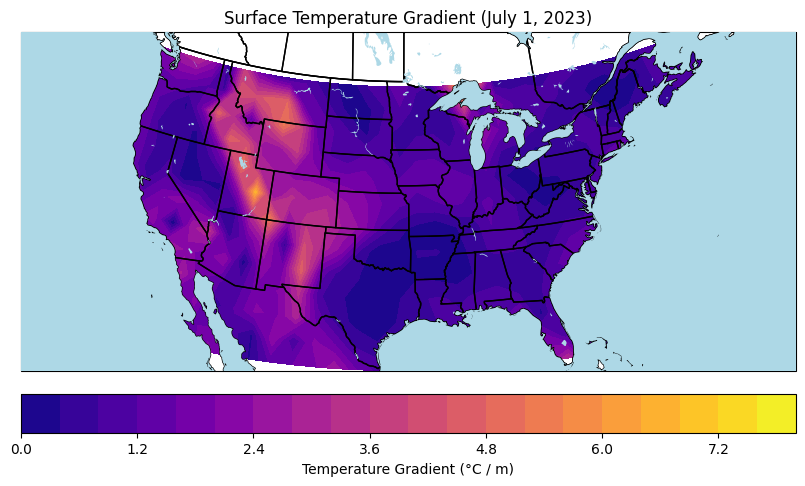

In [4]:
# plot temp gradient
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-95))

# plot gradient magnitude
cs = ax.contourf(lon2d, lat2d, gradT_mag.m, levels=20,
                 transform=ccrs.PlateCarree(), cmap="plasma")

# add map features to make it look pretty
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=9)
ax.add_feature(cfeature.LAKES, facecolor='lightblue')

# plot a colorbar with labels
plt.colorbar(cs, orientation='horizontal', pad=0.05, label="Temperature Gradient (°C / m)")

plt.title("Surface Temperature Gradient (July 1, 2023)")

plt.show()

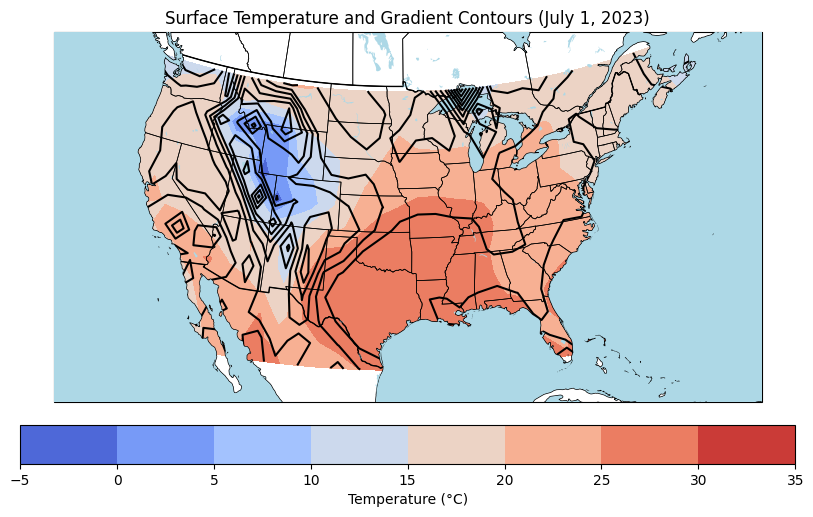

In [5]:
# plot temperature and temp gradient magnitude contours
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection': ccrs.LambertConformal()})

# plot temp
c1 = ax.contourf(lon2d, lat2d, temp.metpy.convert_units('degC'), cmap='coolwarm', transform=ccrs.PlateCarree())
ax.contour(lon2d, lat2d, gradT_mag.m, levels=10, colors='k', transform=ccrs.PlateCarree())
# different way to set a title
ax.set_title("Surface Temperature and Gradient Contours (July 1, 2023)")

# add map features
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.LAKES, facecolor='lightblue')
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=10)
ax.set_extent([-125, -65, 20, 50])  # CONUS extent

# plot colorbar
plt.colorbar(c1, ax=ax, orientation='horizontal', pad=0.05, label='Temperature (\N{DEGREE SIGN}C)')

plt.show()

### Pressure Gradient
Now let's try the same thing with a pressure gradient.

In [6]:
# load sea level pressure dataset
url_slp = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface/slp.2023.nc"
ds_slp = xr.open_dataset(url_slp)

# select the same region and time as our temp data
slp_us = ds_slp.sel(time="2023-07-01", lat=slice(50, 25), lon=slice(230, 300))

slp_us  # print metadata

<xarray.Dataset>
Dimensions:  (lat: 11, lon: 29, time: 4)
Coordinates:
  * lat      (lat) float32 50.0 47.5 45.0 42.5 40.0 ... 35.0 32.5 30.0 27.5 25.0
  * lon      (lon) float32 230.0 232.5 235.0 237.5 ... 292.5 295.0 297.5 300.0
  * time     (time) datetime64[ns] 2023-07-01 ... 2023-07-01T18:00:00
Data variables:
    slp      (time, lat, lon) float32 ...
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2022/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    _NCProperties:                   version=2,netcdf=4.7.0,hdf5=1.10.5,
    DODS_EXTRA.Unlimited_Dimension:  time

In [7]:
# convert Pa to hPa
# slp = slp_us['slp'].isel(time=0).metpy.convert_units('Pa') # won't work bc dataset label is "Pascals" when "pascals" is expected
slp = slp_us['slp'].isel(time=0) / 100.0 # alternate hPa conversion method

# define coordinates - we need to repeat this for new dataset since we have different array size
lats_p = slp_us['lat'].values
lons_p = slp_us['lon'].values
lon2d_p, lat2d_p = np.meshgrid(lons_p, lats_p)    # create 2d arrays for coords

# calc gradients (hPa per degree lat/lon)
dPdy, dPdx = mpcalc.gradient(slp, coordinates=(lat2d_p, lon2d_p))
gradP_mag = np.sqrt(dPdx**2 + dPdy**2)

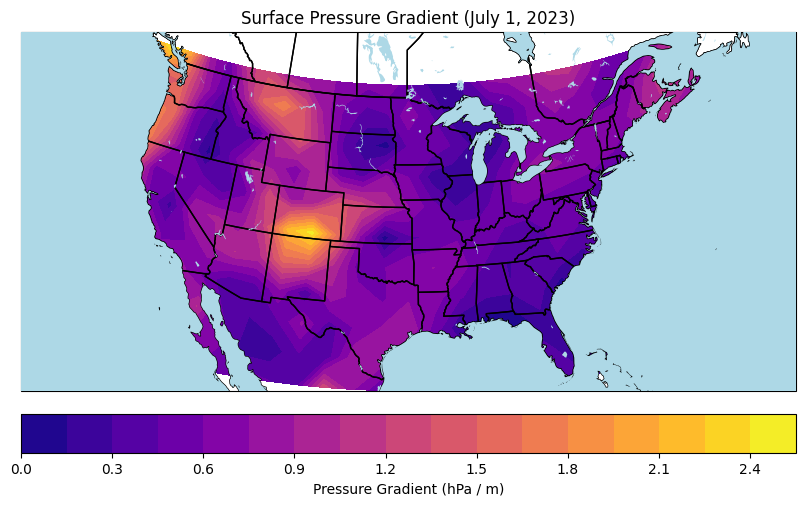

In [8]:
# plot pres gradient
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-95))

# plot gradient magnitude
cs = ax.contourf(lon2d_p, lat2d_p, gradP_mag.m, levels=20,
                 transform=ccrs.PlateCarree(), cmap="plasma")

# add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=9)
ax.add_feature(cfeature.LAKES, facecolor='lightblue')

# colorbar and title
plt.colorbar(cs, orientation='horizontal', pad=0.05, label="Pressure Gradient (hPa / m)")
plt.title("Surface Pressure Gradient (July 1, 2023)")
plt.show()

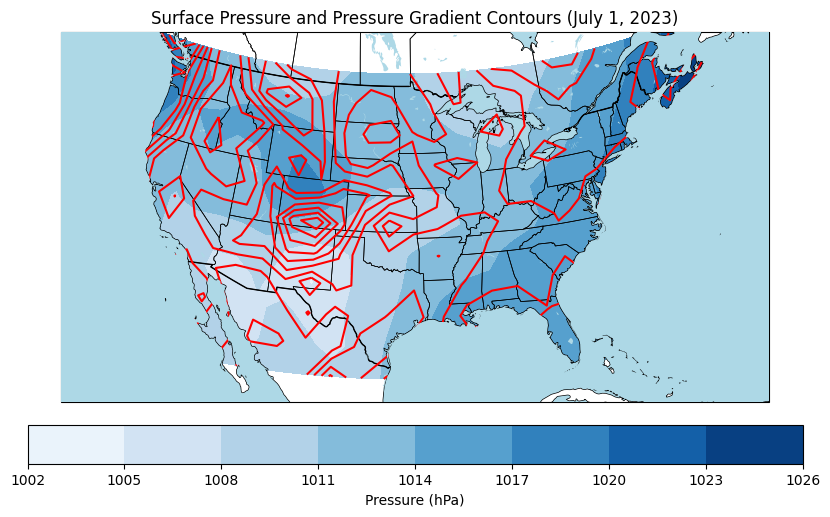

In [9]:
# plot pressure and pressure gradient magnitude contours
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection': ccrs.LambertConformal()})

# plot pressure
c2 = ax.contourf(lon2d_p, lat2d_p, slp, cmap='Blues', transform=ccrs.PlateCarree())  # hPa
ax.contour(lon2d_p, lat2d_p, gradP_mag.m, levels=10, colors='r', transform=ccrs.PlateCarree())
ax.set_title("Surface Pressure and Pressure Gradient Contours (July 1, 2023)")

# add map features
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.LAKES, facecolor='lightblue')
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=8)
ax.set_extent([-125, -65, 20, 50])  # CONUS extent - optional vs. automatic scaline if you don't use

# colorbar
plt.colorbar(c2, ax=ax, orientation='horizontal', pad=0.05, label='Pressure (hPa)')

plt.show()

#### Questions
1. Where are temperature gradients strongest over the US? Why might this be the case?  
2. Compare the regions of strongest temperature gradients to those of strongest pressure gradients. Do they occur in similar areas?  
3. Think about weather systems — how are pressure gradients related to wind?  

### Challenge!

Identify data of interest to you (e.g., pressure, temp, heights, water vapor, winds at different heights/pressure lvls 500mb, 850mb, etc.) for a date of interest to you. Plot the variable and the gradient just as we did above.

In [1]:
# load your data


In [2]:
# set conversions, coordinates, and data definitions


In [3]:
# plot


#### Questions

1. What date did you choose and why?
2. What data did you choose for that date and why?
3. When thinking about the meteorologcal event you choose, how does a plot of your chosen gradient inform you about the event?
4. What other data would be useful to plot when analyzing this event?